# 동영님 전처리 코드로 1차 전처리

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [26]:
df_raw= pd.read_csv('rotten_tomatoes_movie_reviews.csv')
df = pd.read_csv('rotten_tomatoes_movies.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143258 entries, 0 to 143257
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    143258 non-null  object 
 1   title                 142891 non-null  object 
 2   audienceScore         73248 non-null   float64
 3   tomatoMeter           33877 non-null   float64
 4   rating                13991 non-null   object 
 5   ratingContents        13991 non-null   object 
 6   releaseDateTheaters   30773 non-null   object 
 7   releaseDateStreaming  79420 non-null   object 
 8   runtimeMinutes        129431 non-null  float64
 9   genre                 132175 non-null  object 
 10  originalLanguage      129400 non-null  object 
 11  director              139041 non-null  object 
 12  writer                90116 non-null   object 
 13  boxOffice             14743 non-null   object 
 14  distributor           23001 non-null   object 
 15  

In [27]:
df.shape

(143258, 16)

In [28]:
df.head()

,id,title,audienceScore,tomatoMeter,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,writer,boxOffice,distributor,soundMix
0,space-zombie-bingo,Space Zombie Bingo!,50.0,NaN,NaN,NaN,NaN,2018-08-25,75.0,"Comedy, Horror, Sci-fi",English,George Ormrod,"George Ormrod,John Sabotta",NaN,NaN,NaN
1,the_green_grass,The Green Grass,NaN,NaN,NaN,NaN,NaN,2020-02-11,114.0,Drama,English,Tiffany Edwards,Tiffany Edwards,NaN,NaN,NaN
2,love_lies,"Love, Lies",43.0,NaN,NaN,NaN,NaN,NaN,120.0,Drama,Korean,"Park Heung-Sik,Heung-Sik Park","Ha Young-Joon,Jeon Yun-su,Song Hye-jin",NaN,NaN,NaN
3,the_sore_losers_1997,Sore Losers,60.0,NaN,NaN,NaN,NaN,2020-10-23,90.0,"Action, Mystery & thriller",English,John Michael McCarthy,John Michael McCarthy,NaN,NaN,NaN
4,dinosaur_island_2002,Dinosaur Island,70.0,NaN,NaN,NaN,NaN,2017-03-27,80.0,"Fantasy, Adventure, Animation",English,Will Meugniot,John Loy,NaN,NaN,NaN


In [29]:
df_raw.head()

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),Timed to be just long enough for most youngste...,POSITIVE,http://www.deseretnews.com/article/700003233/B...
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,It doesn't matter if a movie costs 300 million...,NEGATIVE,http://www.dreadcentral.com/index.php?name=Rev...
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,The choreography is so precise and lifelike at...,POSITIVE,https://www.cbr.com/city-hunter-shinjuku-priva...
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may ...,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/0...
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and some...,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerou...


In [30]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1444963 entries, 0 to 1444962
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1444963 non-null  object
 1   reviewId        1444963 non-null  int64 
 2   creationDate    1444963 non-null  object
 3   criticName      1444963 non-null  object
 4   isTopCritic     1444963 non-null  bool  
 5   originalScore   1009745 non-null  object
 6   reviewState     1444963 non-null  object
 7   publicatioName  1444963 non-null  object
 8   reviewText      1375738 non-null  object
 9   scoreSentiment  1444963 non-null  object
 10  reviewUrl       1234038 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 111.6+ MB


In [31]:
df_raw.nunique()

id                  69263
reviewId          1432569
creationDate         8510
criticName          15510
isTopCritic             2
originalScore        1729
reviewState             2
publicatioName       2707
reviewText        1359771
scoreSentiment          2
reviewUrl         1138350
dtype: int64

In [32]:
# 중복 제거 및 index 초기화
df_raw.drop_duplicates(inplace=True)
df_raw.reset_index(drop=True, inplace=True)

In [33]:
# 리뷰 개수 90% 인 기준 산출
df_raw['id'].value_counts().quantile(0.9)

56.0

In [34]:
# 리뷰가 56개 이상인 영화(id)의 index 추출
selected_index_1 = df_raw['id'].value_counts()[df_raw['id'].value_counts()>=56].index

In [35]:
selected_index_1

Index(['joker_2019', 'once_upon_a_time_in_hollywood', 'avengers_endgame',
       'captain_marvel', 'a_star_is_born_2018', 'black_panther_2018',
       'star_wars_the_rise_of_skywalker', 'the_batman', 'dune_2021',
       'avengers_infinity_war',
       ...
       'ginger_snaps', '1090089-jack_frost', 'test_pattern', 'claires_camera',
       'the_wound_2017', 'the_mad_womens_ball', 'days_of_heaven',
       'broken_2012', '1104207-panic',
       'jeanne_dielman_23_quai_du_commerce_1080_bruxelles'],
      dtype='object', name='id', length=6963)

In [36]:
# 추출된 Index로 df_raw에서 리뷰 데이터 추출
selected_df = df_raw[df_raw['id'].isin(selected_index_1)]

In [37]:
# index 초기화
selected_df.reset_index(drop=True, inplace= True)

In [38]:
selected_df

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,the_duff,2763233,2021-02-02,Richard Crouse,False,3/5,fresh,Richard Crouse,A school comedy so predictable the screenwrite...,POSITIVE,http://www.richardcrouse.ca/the-duff-3-stars-a...
1,the_duff,2692661,2020-05-27,Andrew Galdi,False,NaN,fresh,Movie Bitches,It was good acting and good writing.,POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
2,the_duff,2679627,2020-03-26,Avaryl Halley,False,NaN,fresh,Movie Bitches,"Oh dear, am I the Duff?",POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
3,the_duff,2615809,2019-08-15,Udita Jhunjhunwala,True,NaN,fresh,Livemint,While director Ari Sandel's adaptation is devo...,POSITIVE,https://www.livemint.com/Leisure/3wDs58QVt0Mtm...
4,the_duff,2586271,2019-05-14,Olivia Luder,True,3/5,fresh,One Room With A View,Not clever enough to be genre-defining in its ...,POSITIVE,https://oneroomwithaview.com/2015/03/06/duff-r...
...,...,...,...,...,...,...,...,...,...,...,...
925866,thor_love_and_thunder,102706151,2022-07-05,Christie Cronan,False,7/10,fresh,Raising Whasians,Solid but not totally sold&#44; Thor&#58; Ragn...,POSITIVE,https://raisingwhasians.com/thor-love-and-thun...
925867,thor_love_and_thunder,102706150,2022-07-05,Ian Sandwell,False,4/5,fresh,Digital Spy,Thor&#58; Love and Thunder is the most enterta...,POSITIVE,https://www.digitalspy.com/movies/a40496050/th...
925868,thor_love_and_thunder,102706149,2022-07-05,Lauren LaMagna,False,8/10,fresh,Next Best Picture,&quot;Thor&#58; Love and Thunder&quot; is a st...,POSITIVE,https://www.nextbestpicture.com/thor-love-and-...
925869,thor_love_and_thunder,102706148,2022-07-05,Jake Cole,True,1/4,rotten,Slant Magazine,Across Taika Waititi&#8217;s film&#44; a war a...,NEGATIVE,https://www.slantmagazine.com/film/thor-love-a...


In [39]:
# 리뷰를 4개이상한 리뷰어들의 index 추출
selected_index_2 = selected_df['criticName'].value_counts()[selected_df['criticName'].value_counts()>=4].index

In [40]:
selected_index_2

Index(['Frank Swietek', 'Roger Moore', 'Brian Orndorf', 'Jeffrey M. Anderson',
       'Rich Cline', 'Nell Minow', 'Laura Clifford', 'James Berardinelli',
       'Dennis Schwartz', 'David Nusair',
       ...
       'Anne Crump', 'Simon Guerrier', 'Valeriy Kolyadych',
       'Juan José Ontiveros', 'Megan Moffat', 'Mekeisha Madden Toby',
       'Hannah Chambers', 'Philip Horne', 'Jerrica Tisdale', 'Rob Beames'],
      dtype='object', name='criticName', length=6093)

In [41]:
# 추출된 Index로 selected_df에서 리뷰 데이터(final_df) 추출
final_df = selected_df[selected_df['criticName'].isin(selected_index_2)]
final_df

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,the_duff,2763233,2021-02-02,Richard Crouse,False,3/5,fresh,Richard Crouse,A school comedy so predictable the screenwrite...,POSITIVE,http://www.richardcrouse.ca/the-duff-3-stars-a...
1,the_duff,2692661,2020-05-27,Andrew Galdi,False,NaN,fresh,Movie Bitches,It was good acting and good writing.,POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
2,the_duff,2679627,2020-03-26,Avaryl Halley,False,NaN,fresh,Movie Bitches,"Oh dear, am I the Duff?",POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
3,the_duff,2615809,2019-08-15,Udita Jhunjhunwala,True,NaN,fresh,Livemint,While director Ari Sandel's adaptation is devo...,POSITIVE,https://www.livemint.com/Leisure/3wDs58QVt0Mtm...
4,the_duff,2586271,2019-05-14,Olivia Luder,True,3/5,fresh,One Room With A View,Not clever enough to be genre-defining in its ...,POSITIVE,https://oneroomwithaview.com/2015/03/06/duff-r...
...,...,...,...,...,...,...,...,...,...,...,...
925866,thor_love_and_thunder,102706151,2022-07-05,Christie Cronan,False,7/10,fresh,Raising Whasians,Solid but not totally sold&#44; Thor&#58; Ragn...,POSITIVE,https://raisingwhasians.com/thor-love-and-thun...
925867,thor_love_and_thunder,102706150,2022-07-05,Ian Sandwell,False,4/5,fresh,Digital Spy,Thor&#58; Love and Thunder is the most enterta...,POSITIVE,https://www.digitalspy.com/movies/a40496050/th...
925868,thor_love_and_thunder,102706149,2022-07-05,Lauren LaMagna,False,8/10,fresh,Next Best Picture,&quot;Thor&#58; Love and Thunder&quot; is a st...,POSITIVE,https://www.nextbestpicture.com/thor-love-and-...
925869,thor_love_and_thunder,102706148,2022-07-05,Jake Cole,True,1/4,rotten,Slant Magazine,Across Taika Waititi&#8217;s film&#44; a war a...,NEGATIVE,https://www.slantmagazine.com/film/thor-love-a...


In [42]:
final_df.reset_index(drop=True,inplace=True)

In [44]:
final_df

,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,the_duff,2763233,2021-02-02,Richard Crouse,False,3/5,fresh,Richard Crouse,A school comedy so predictable the screenwrite...,POSITIVE,http://www.richardcrouse.ca/the-duff-3-stars-a...
1,the_duff,2692661,2020-05-27,Andrew Galdi,False,NaN,fresh,Movie Bitches,It was good acting and good writing.,POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
2,the_duff,2679627,2020-03-26,Avaryl Halley,False,NaN,fresh,Movie Bitches,"Oh dear, am I the Duff?",POSITIVE,https://www.youtube.com/watch?v=8KeoWwUtXVQ&li...
3,the_duff,2615809,2019-08-15,Udita Jhunjhunwala,True,NaN,fresh,Livemint,While director Ari Sandel's adaptation is devo...,POSITIVE,https://www.livemint.com/Leisure/3wDs58QVt0Mtm...
4,the_duff,2586271,2019-05-14,Olivia Luder,True,3/5,fresh,One Room With A View,Not clever enough to be genre-defining in its ...,POSITIVE,https://oneroomwithaview.com/2015/03/06/duff-r...
...,...,...,...,...,...,...,...,...,...,...,...
917410,thor_love_and_thunder,102706151,2022-07-05,Christie Cronan,False,7/10,fresh,Raising Whasians,Solid but not totally sold&#44; Thor&#58; Ragn...,POSITIVE,https://raisingwhasians.com/thor-love-and-thun...
917411,thor_love_and_thunder,102706150,2022-07-05,Ian Sandwell,False,4/5,fresh,Digital Spy,Thor&#58; Love and Thunder is the most enterta...,POSITIVE,https://www.digitalspy.com/movies/a40496050/th...
917412,thor_love_and_thunder,102706149,2022-07-05,Lauren LaMagna,False,8/10,fresh,Next Best Picture,&quot;Thor&#58; Love and Thunder&quot; is a st...,POSITIVE,https://www.nextbestpicture.com/thor-love-and-...
917413,thor_love_and_thunder,102706148,2022-07-05,Jake Cole,True,1/4,rotten,Slant Magazine,Across Taika Waititi&#8217;s film&#44; a war a...,NEGATIVE,https://www.slantmagazine.com/film/thor-love-a...


In [63]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917415 entries, 0 to 917414
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              917415 non-null  object
 1   reviewId        917415 non-null  int64 
 2   creationDate    917415 non-null  object
 3   criticName      917415 non-null  object
 4   isTopCritic     917415 non-null  bool  
 5   originalScore   664266 non-null  object
 6   reviewState     917415 non-null  object
 7   publicatioName  917415 non-null  object
 8   reviewText      900311 non-null  object
 9   scoreSentiment  917415 non-null  object
 10  reviewUrl       794784 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 70.9+ MB


# 개인적 전처리 _ 2차 전처리

## 영화랑 리뷰어에 고유 인덱스 부여하기

In [413]:
mydf = final_df[['id', 'criticName', 'originalScore']]
mydf = mydf.dropna() #Nan 값 있는거 모두 제거

In [414]:
#movie id 인덱스 만들어주기
movie_id = list(mydf['id'].unique())
movie_dict = {movie: idx + 1 for idx, movie in enumerate(movie_id)}

movie_id_tmp = []
for id in mydf['id']:
    movie_id_tmp.append(movie_dict[id])
mydf['movieId'] = movie_id_tmp

#user id 인덱스 만들어주기
user_id = list(mydf['criticName'].unique())
user_dict = {user: idx + 1 for idx, user in enumerate(user_id)}

user_id_tmp = []
for id in mydf['criticName']:
    user_id_tmp.append(user_dict[id])

mydf['userId'] = user_id_tmp

## originalScore 정제

In [415]:
# 숫자 척도만 사용
mydf = mydf[mydf['originalScore'].str.contains('/')]

In [416]:
# / 뒤 제거
mydf['originalScore'] = mydf['originalScore'].str.replace("'",'')
mydf['originalScore'] = mydf['originalScore'].str.replace("10-",'10')
mydf['originalScore'] = mydf['originalScore'].str.replace("5w",'5')
mydf = mydf.drop(mydf[mydf['originalScore'].str.split('/', expand=True)[1] == "2`"].index) 
mydf = mydf.drop(mydf[mydf['originalScore'].str.split('/', expand=True)[1] == ".5"].index) 
mydf = mydf.drop(mydf[mydf['originalScore'].str.split('/', expand=True)[1] == ".0"].index) 
mydf = mydf.drop(mydf[mydf['originalScore'].str.split('/', expand=True)[1] == ""].index) 
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('stars')].index) # 척도가 없음
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('5Too tepid and too predictable of a picture to')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('4ANNAPOL')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('2 pink ponies out of five')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('4A')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('5ao')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('B-')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('2 star')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('2  out of 4')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('4The best that can be said about the movie is th')].index) # 어차피 1개

# / 앞 제거
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('*',regex=False)].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('w.5')].index) # 어차피 1개
mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('4The best that can be said about the movie is th')].index) # 어차피 1개

mydf['originalScore'] = mydf['originalScore'].str.replace("2.5.",'2.5')
#mydf = mydf.drop(mydf[mydf['originalScore'].str.contains('')].index) # 어차피 3개
# mydf['originalScore'] = mydf['originalScore'].str.replace(" ",'')

tmp = mydf['originalScore'].str.split('/', expand=True)
tmp[1] = tmp[1].str.replace(' ', '')
tmp[0] = tmp[0].str.replace(' ', '')
tmp[1] = tmp[1].astype(float)
tmp[0] = tmp[0].astype(float)
tmp.columns =['rating','standard', 'None']
df = pd.concat([mydf, tmp], axis=1)
df = df.drop(df[df['standard']==0].index) #척도가 0인 애들 제외

df

,id,criticName,originalScore,movieId,userId,rating,standard,None
0,the_duff,Richard Crouse,3/5,1,1,3.0,5.0,None
4,the_duff,Olivia Luder,3/5,1,2,3.0,5.0,None
6,the_duff,Bernard Boo,7/10,1,4,7.0,10.0,None
12,the_duff,Mark Jackson,3/5,1,8,3.0,5.0,None
13,the_duff,Latoya Newman,3/5,1,9,3.0,5.0,None
...,...,...,...,...,...,...,...,...
917410,thor_love_and_thunder,Christie Cronan,7/10,6963,899,7.0,10.0,None
917411,thor_love_and_thunder,Ian Sandwell,4/5,6963,857,4.0,5.0,None
917412,thor_love_and_thunder,Lauren LaMagna,8/10,6963,3683,8.0,10.0,None
917413,thor_love_and_thunder,Jake Cole,1/4,6963,930,1.0,4.0,None


In [417]:
# 척도 10으로 맞추고 rating 다시 계산해서 rating_new 에 넣기
rating = df['rating'].to_list()
standard = df['standard'].to_list()

rating_new = [(5/a)*b for a, b in zip(standard, rating)]
df['rating_new'] = rating_new
real_final_df = df[['userId','movieId','rating_new']]
real_final_df = real_final_df.reset_index(drop=True)
real_final_df

,userId,movieId,rating_new
0,1,1,3.000
1,2,1,3.000
2,4,1,3.500
3,8,1,3.000
4,9,1,3.000
...,...,...,...
547891,899,6963,3.500
547892,857,6963,4.000
547893,3683,6963,4.000
547894,930,6963,1.250


In [ ]:
# real_final_df.to_csv('data_mf.csv')

In [418]:
real_final_df.to_csv('data_mf_5.csv')

# 하나의 영화에 대해 비슷한 영화 추천해주기(상관계수,SVD 활용)

https://github.com/lsjsj92/recommender_system_with_Python/blob/master/004.%20recommender%20system%20basic%20with%20Python%20-%203%20Matrix%20Factorization.ipynb

In [419]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [422]:
data = real_final_df.copy()

In [426]:
user_movie_rating = data.pivot_table('rating_new', index = 'userId', columns='movieId').fillna(0)
user_movie_rating.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,6954,6955,6956,6957,6958,6959,6960,6961,6962,6963
userId,,,,,,,,,,,,,,,,,,,,,
1,3.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,1.0,3.5,3.0,4.0,4.5,0.0,4.0
2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,3.5,0.0,0.0,0.0,2.5,0.0,3.5,0.0,3.0
4,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [427]:
movie_user_rating = user_movie_rating.values.T
movie_user_rating.shape

(6963, 4253)

In [428]:
type(movie_user_rating)

numpy.ndarray

# SVD 사용

In [430]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse.linalg import svds

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [431]:
SVD = TruncatedSVD(n_components=12)
matrix = SVD.fit_transform(movie_user_rating)
matrix.shape

(6963, 12)

In [432]:
matrix[0]

array([ 1.31251546e-06,  1.05309044e+01, -2.87439745e+00,  4.20423422e+00,
        3.12854368e+00,  1.66426244e+00, -1.61436041e+00,  2.62210455e+00,
       -4.32510711e-01,  4.30205419e+00,  4.66130476e+00,  8.63332096e-01])

In [433]:
corr = np.corrcoef(matrix)
corr.shape

(6963, 6963)

In [434]:
corr2 = corr[:200, :200]
corr2.shape

(200, 200)

<Axes: >

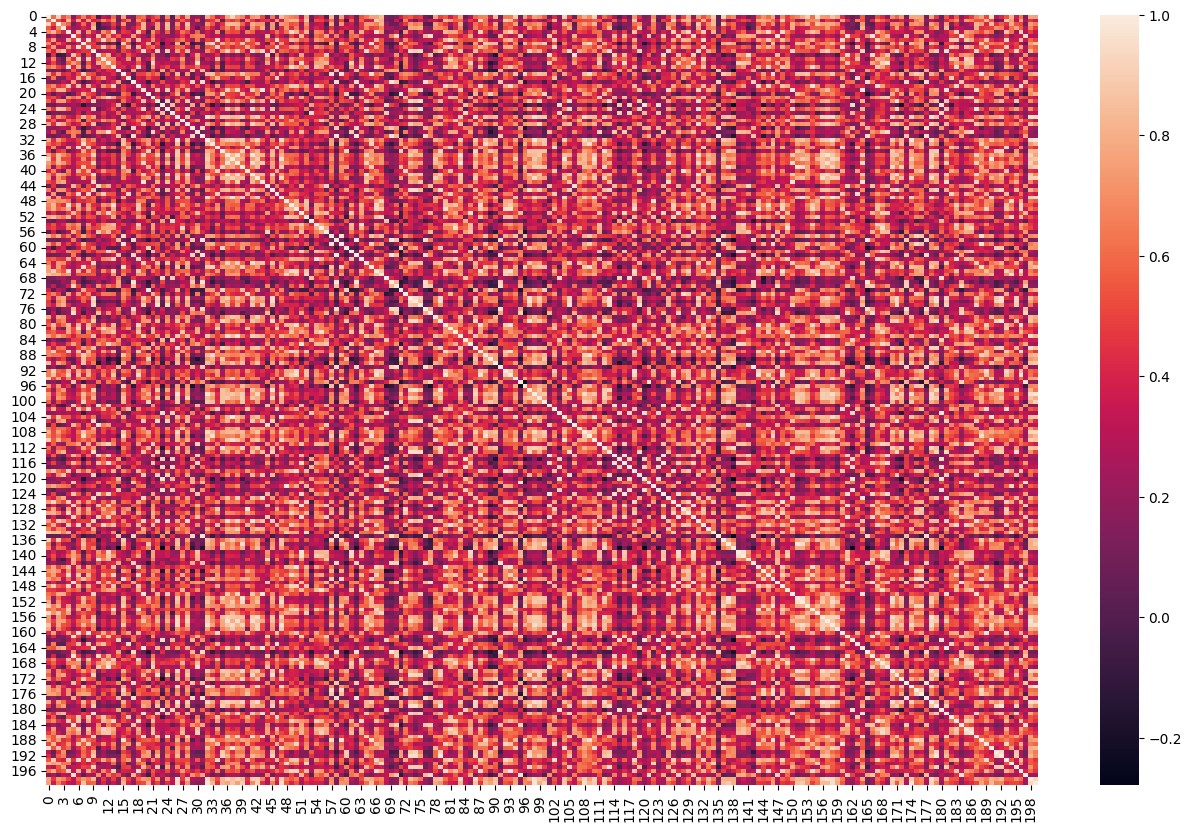

In [435]:
plt.figure(figsize=(16, 10))
sns.heatmap(corr2)

In [438]:
movie_title = user_movie_rating.columns
movie_title_list = list(movie_title)
coffey_hands = movie_title_list.index(4)

In [ ]:
corr_coffey_hands  = corr[coffey_hands]
list(movie_title[(corr_coffey_hands >= 0.9)])[:50] # 특정 영화와 상관계수가 높은 영화 추출

[4,
 305,
 355,
 516,
 1101,
 1118,
 2072,
 2820,
 2972,
 3434,
 3459,
 3783,
 4195,
 4603,
 5293,
 6084,
 6492,
 6539]

# 한 사용자에게 개인 추천

In [441]:
user_movie_rating.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,6954,6955,6956,6957,6958,6959,6960,6961,6962,6963
userId,,,,,,,,,,,,,,,,,,,,,
1,3.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,1.0,3.5,3.0,4.0,4.5,0.0,4.0
2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,3.5,0.0,0.0,0.0,2.5,0.0,3.5,0.0,3.0
4,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [445]:
# matrix는 pivot_table 값을 numpy matrix로 만든 것 
matrix = user_movie_rating.to_numpy()

# user_ratings_mean은 사용자의 평균 평점 
user_ratings_mean = np.mean(matrix, axis = 1)

# R_user_mean : 사용자-영화에 대해 사용자 평균 평점을 뺀 것.
matrix_user_mean = matrix - user_ratings_mean.reshape(-1, 1)

In [447]:
pd.DataFrame(matrix_user_mean, columns = user_movie_rating.columns).head()

movieId,1,2,3,4,5,6,7,8,9,10,...,6954,6955,6956,6957,6958,6959,6960,6961,6962,6963
0,2.462875,-0.537125,1.462875,2.462875,-0.537125,-0.537125,-0.537125,-0.537125,-0.537125,-0.537125,...,-0.537125,3.462875,-0.537125,0.462875,2.962875,2.462875,3.462875,3.962875,-0.537125,3.462875
1,2.997989,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,...,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011,-0.002011
2,-0.297573,-0.297573,-0.297573,-0.297573,-0.297573,-0.297573,-0.297573,-0.297573,-0.297573,1.702427,...,-0.297573,3.202427,-0.297573,-0.297573,-0.297573,2.202427,-0.297573,3.202427,-0.297573,2.702427
3,3.372497,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,...,-0.127503,3.872497,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503,-0.127503
4,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,...,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718,-0.000718


In [448]:
# scipy에서 제공해주는 svd.  
# U 행렬, sigma 행렬, V 전치 행렬을 반환.

U, sigma, Vt = svds(matrix_user_mean, k = 12)

In [449]:
print(U.shape)
print(sigma.shape)
print(Vt.shape)

(4253, 12)
(12,)
(12, 6963)


In [450]:
sigma = np.diag(sigma)
sigma.shape

(12, 12)

In [451]:
sigma[0]

array([188.621901,   0.      ,   0.      ,   0.      ,   0.      ,
         0.      ,   0.      ,   0.      ,   0.      ,   0.      ,
         0.      ,   0.      ])

In [452]:
# U, Sigma, Vt의 내적을 수행하면, 다시 원본 행렬로 복원이 된다. 
# 거기에 + 사용자 평균 rating을 적용한다. 
svd_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

In [453]:
df_svd_preds = pd.DataFrame(svd_user_predicted_ratings, columns = user_movie_rating.columns)
df_svd_preds.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,6954,6955,6956,6957,6958,6959,6960,6961,6962,6963
0,1.043157,0.154326,0.419299,0.535153,0.256566,-0.020039,-0.407050,0.493150,-0.350577,1.834323,...,1.311409,4.081557,0.313681,1.262462,1.608643,2.322566,2.213351,4.680416,1.299629,3.426030
1,0.010828,0.002275,0.003054,0.001841,0.001114,-0.000070,-0.004175,0.007641,-0.002394,-0.001319,...,-0.001199,-0.007537,-0.001577,0.010200,0.003273,-0.001280,0.015152,0.001036,-0.002826,-0.004501
2,-0.069801,0.005027,0.135835,0.341587,0.196145,0.069722,-0.036594,-0.078133,-0.197129,1.413162,...,1.190309,3.312011,0.218798,0.132000,0.999906,1.745722,0.302512,3.668872,1.239056,2.728960
3,0.566694,0.127950,0.155879,0.037299,0.008292,0.041437,-0.112869,0.350676,0.005125,-0.043409,...,0.074794,-0.064843,-0.016690,0.625740,0.122088,-0.008346,1.081588,0.039461,-0.021284,-0.016315
4,0.000017,0.001119,0.000547,0.000204,0.000509,0.005643,0.002374,0.000109,0.001683,0.000245,...,0.000521,0.002221,0.000361,0.000326,0.000107,0.000564,-0.000084,-0.001226,0.000210,0.000749


In [454]:
df_svd_preds.shape

(4253, 6963)

In [471]:
def recommend_movies(df_svd_preds, userId, ori_movies_df, ori_ratings_df, num_recommendations=5):
    
    #현재는 index로 적용이 되어있으므로 userId - 1을 해야함.
    user_row_number = userId - 1 
    
    # 최종적으로 만든 pred_df에서 사용자 index에 따라 영화 데이터 정렬 -> 영화 평점이 높은 순으로 정렬 됌
    sorted_user_predictions = df_svd_preds.iloc[user_row_number].sort_values(ascending=False)
    
    # 원본 평점 데이터에서 user id에 해당하는 데이터를 뽑아낸다. 
    user_data = ori_ratings_df[ori_ratings_df.userId == userId]
    
    # 위에서 뽑은 user_data와 원본 영화 데이터를 합친다. 
    user_history = user_data.merge(ori_movies_df, on = 'movieId').sort_values(['rating_new'], ascending=False)
    
    # 원본 영화 데이터에서 사용자가 본 영화 데이터를 제외한 데이터를 추출
    recommendations = ori_movies_df[~ori_movies_df['movieId'].isin(user_history['movieId'])]
    # 사용자의 영화 평점이 높은 순으로 정렬된 데이터와 위 recommendations을 합친다. 
    recommendations = recommendations.merge( pd.DataFrame(sorted_user_predictions).reset_index(), on = 'movieId')
    # 컬럼 이름 바꾸고 정렬해서 return
    recommendations = recommendations.rename(columns = {user_row_number: 'Predictions'}).sort_values('Predictions', ascending = False).iloc[:num_recommendations, :]
                      

    return user_history, recommendations

In [473]:
already_rated, predictions = recommend_movies(df_svd_preds, 330, data['movieId'].to_frame(), data[['userId', 'movieId','rating_new']], 10)

In [474]:
already_rated

,userId,movieId,rating_new
45502,330,3148,5.0
61552,330,4194,5.0
61545,330,4194,5.0
61546,330,4194,5.0
61547,330,4194,5.0
...,...,...,...
43141,330,3051,0.0
43142,330,3051,0.0
43143,330,3051,0.0
43144,330,3051,0.0


In [475]:
predictions

,movieId,Predictions
448229,6945,0.060883
448259,6945,0.060883
448261,6945,0.060883
448262,6945,0.060883
448263,6945,0.060883
448264,6945,0.060883
448265,6945,0.060883
448266,6945,0.060883
448267,6945,0.060883
448268,6945,0.060883


# 모델 학습 (이건 그냥 -> 학습 안됨)

In [420]:
data = real_final_df.copy()

In [421]:
train, test = train_test_split(data, test_size=0.3)

In [406]:
# 사용자와 아이템 수 계산
num_users = max(train['userId']) + 1  # userId의 최대값 + 1
num_items = max(train['movieId']) + 1  # movieId의 최대값 + 1

In [407]:
users = torch.tensor(train['userId'].values)
items = torch.tensor(train['movieId'].values)
ratings = torch.tensor(train['rating_new'].values, dtype=torch.float)

In [408]:
dataset = TensorDataset(users, items, ratings)
dataloader = DataLoader(dataset, batch_size=1000, shuffle=True)

In [409]:
latent_dim = 30
learning_rate = 0.001  # 작은 학습률
num_epochs = 1000

In [410]:
# 모델 정의
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, latent_dim):
        super(MatrixFactorization, self).__init__()
        self.user_embeddings = nn.Embedding(num_users, latent_dim)
        self.item_embeddings = nn.Embedding(num_items, latent_dim)
        
        # 임베딩 초기화|
        nn.init.normal_(self.user_embeddings.weight, std=0.001)
        nn.init.normal_(self.item_embeddings.weight, std=0.001)

    def forward(self, user_indices, item_indices):
        user_latent = self.user_embeddings(user_indices)
        item_latent = self.item_embeddings(item_indices)
        return (user_latent * item_latent).sum(dim=1)

In [411]:
model = MatrixFactorization(num_users, num_items, latent_dim).to("cpu")
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [412]:
# 학습
for epoch in range(num_epochs):
    total_loss = 0.0
    for user_idx, item_idx, rating in dataloader:
        user_idx, item_idx, rating = user_idx.to("cpu"), item_idx.to("cpu"), rating.to("cpu")

        optimizer.zero_grad()
        prediction = model(user_idx, item_idx)
        prediction = torch.clamp(prediction, min=0, max=5)  # 예측 값 제한
        loss = criterion(prediction, rating)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {total_loss}')

Epoch 1/1000, Loss: 1111111255582.357
Epoch 2/1000, Loss: 1111111255582.167
Epoch 3/1000, Loss: 1111110993437.7383
Epoch 4/1000, Loss: 1111110993438.8916
Epoch 5/1000, Loss: 1111110993438.7305
Epoch 6/1000, Loss: 1111110993438.4673
Epoch 7/1000, Loss: 1111110993439.8918
Epoch 8/1000, Loss: 1111110993439.0315
Epoch 9/1000, Loss: 1111110993438.2712
Epoch 10/1000, Loss: 1111110993437.378
Epoch 11/1000, Loss: 1111110993440.2969
Epoch 12/1000, Loss: 1111110993439.614
Epoch 13/1000, Loss: 1111110993436.7935
Epoch 14/1000, Loss: 1111110993437.1846


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001A95DDA5C00>>
Traceback (most recent call last):
  File "c:\Users\ose06\anaconda3\envs\langchain\lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Epoch 15/1000, Loss: 1111110993439.3909
Epoch 16/1000, Loss: 1111110993438.6902
Epoch 17/1000, Loss: 1111110993438.6494


KeyboardInterrupt: 

In [ ]:
# 테스트
users_test = torch.tensor(test['userId'].values)
items_test = torch.tensor(test['movieId'].values)
ratings_test = torch.tensor(test['rating_new'].values, dtype=torch.float)

test_user_indices, test_item_indices, ratings_test = users_test.to("cpu"), users_test.to("cpu"), ratings_test.to("cpu")

In [ ]:
test_predictions = model(test_user_indices, test_item_indices)
test_loss = criterion(test_predictions, ratings_test)

In [ ]:
# MSE 계산
test_loss = criterion(test_predictions, ratings_test).item()

# RMSE 계산
rmse_loss = test_loss ** 0.5

# 결과 출력
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {rmse_loss:.4f}")